## Linear Regression From Scratch

### 1) Normal Equation

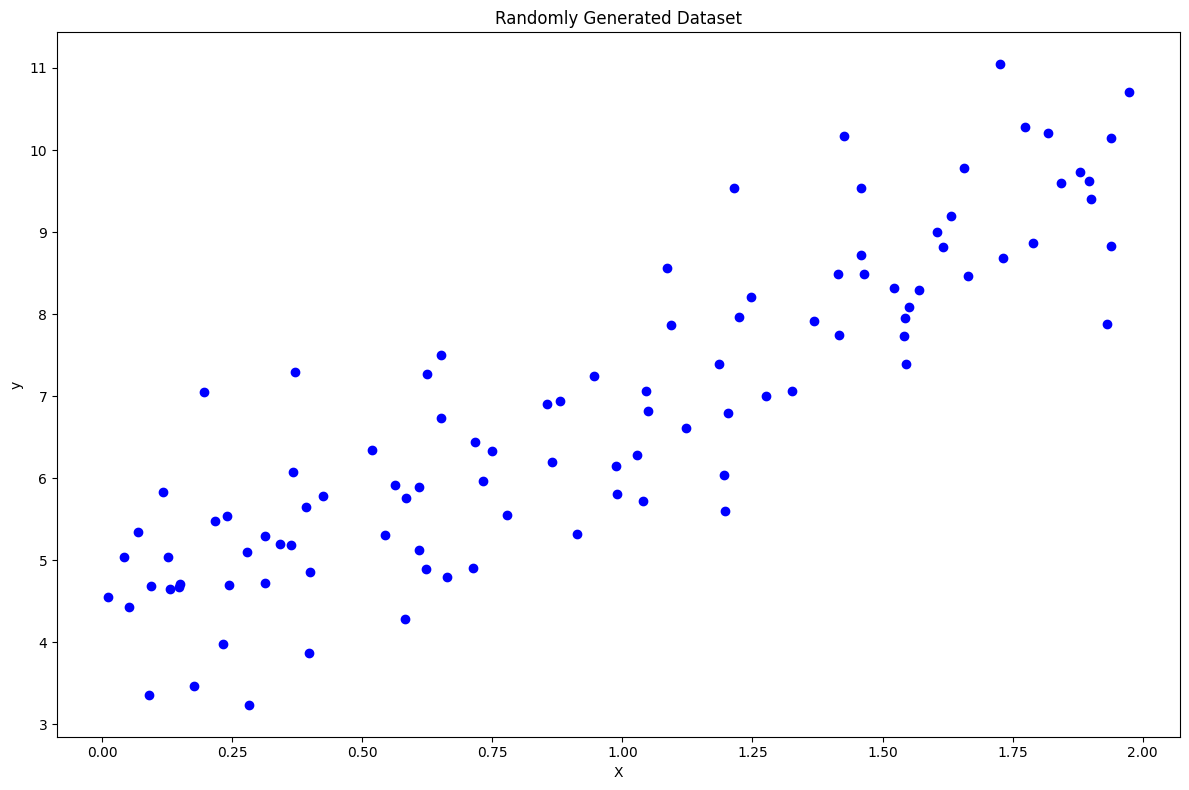

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2*np.random.rand(100,1)
y = 4 + 3*X + np.random.randn(100,1)

fig,ax = plt.subplots(figsize=(12,8))
ax.scatter(X,y,c="blue")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Randomly Generated Dataset")
plt.tight_layout()
plt.show()

Finding best theta to fit the dataset using **Normal Equation** `np.linalg.inv(X^T*X)*X^T*y`

In [3]:
X_b = np.c_[np.ones((100,1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

[[4.21509616]
 [2.77011339]]


In [4]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict = X_new_b.dot(theta_best)
print(y_predict)

[[4.21509616]
 [9.75532293]]


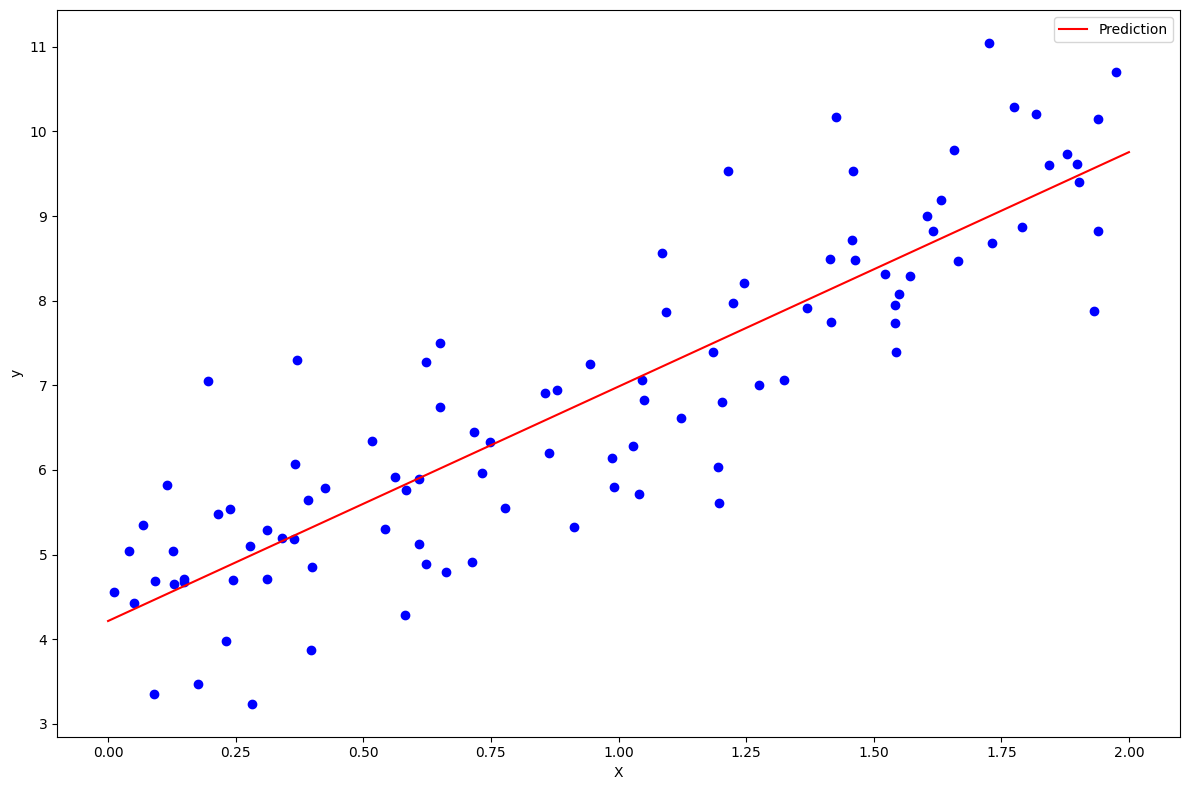

In [5]:
fig,ax = plt.subplots(figsize=(12,8))
ax.scatter(X,y,c="blue")
ax.plot(X_new,y_predict,c="red",label="Prediction")
ax.set_xlabel("X")
ax.set_ylabel("y")
plt.legend()
plt.tight_layout()
plt.show();

**Computational Complexity:** O(n³)

we should avoid this method when we have a large dataset or a big number of features

### 2) Gradient Descent

####  1.Batch Gradient Descent

In [6]:
eta = 0.1 # learning rate
n_iterations = 1000
m = 100

theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    error = X_b.dot(theta) - y
    gradients = (2/m)*X_b.T.dot(error)
    theta = theta - eta*gradients

print(f"Theta found by Gradient Descent: {theta}" )

Theta found by Gradient Descent: [[4.21509616]
 [2.77011339]]


#### 2.Stochastic Gradient Descent 

1. Pick randomly one instance from the m samples.
2. Perform gradient based on that instance only.
3. Update the parameters .
4. Repeat the process for n epochs.

In [7]:
np.random.seed(42)
n_epochs = 50
eta = 0.1
m = 100 # samples

X = np.random.randn(m,1) # (100,1)
y = 3*X+4+np.random.randn(m,1) 

theta = np.random.randn(2,1) # (2,1)

# add bias
X_b = np.c_[np.ones((m,1)),X]

for i in range(n_epochs):
    for j in range(m):
        random_index= np.random.randint(m)
        X_r = X_b[random_index:random_index+1] # (100,2)
        error = X_r.dot(theta) - y[random_index:random_index+1] # (100,1)
        gradients = 2*(X_r.T).dot(error) # (2,1)
        theta = theta - eta*gradients

print(theta)



[[4.20106191]
 [2.93576846]]


### 3.Mini-batch Gradient Descent

In [8]:
np.random.seed(42)

eta = 0.1 # learning rate
m = 10000 # samples
batch_size = 100 # size of batches to make a tiny gradient decision

X = np.random.randn(m,1) # (10000,1)
y = 4+ 3*X + np.random.randn(m,1) # (10000,1)

X_b = np.c_[np.ones((m,1)),X] # (10000,2)

theta = np.random.randn(2,1) # (2,1)

for i in range(100):
    X_t = X_b[batch_size*i:(i+1)*batch_size] # (100,2)
    Y_t = y[batch_size*i:(i+1)*batch_size] # (100,1)
    error = X_t.dot(theta) - Y_t # (100,1)
    gradients = (2/batch_size)*((X_t.T).dot(error)) # (2,1)
    theta = theta - (eta*gradients)
print(theta)

[[4.01500303]
 [3.03600634]]


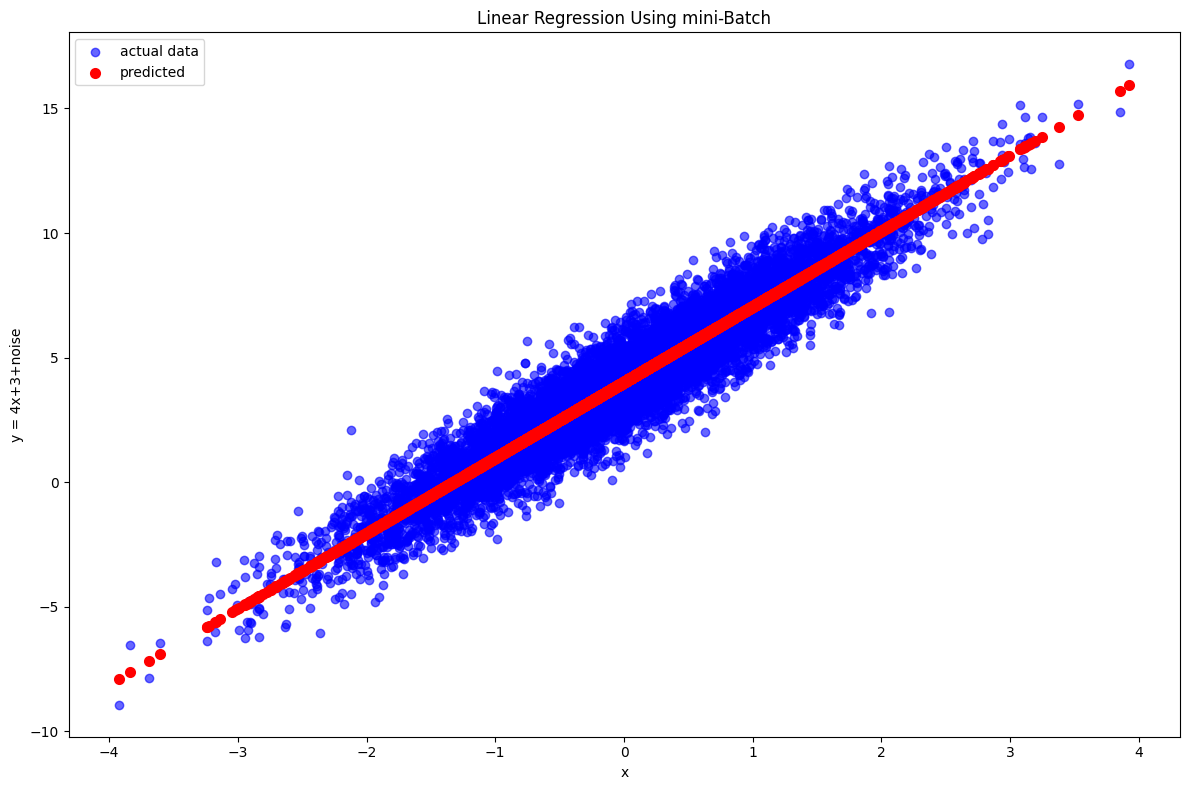

In [9]:
fig,ax = plt.subplots(figsize=(12,8))
ax.scatter(X,y,c="blue",label="actual data",alpha=0.6)
ax.scatter(X,X_b.dot(theta),c="red",label="predicted",linewidth=2)
ax.set_title("Linear Regression Using mini-Batch")
ax.set_xlabel("x")
ax.set_ylabel("y = 4x+3+noise")
plt.tight_layout()
plt.legend()
plt.show()

### 3) Polynomial Regression

[-0.75275929]
[-0.75275929  0.56664654]
1.7813458120291457
0.9336689322536068
0.5645626336170753


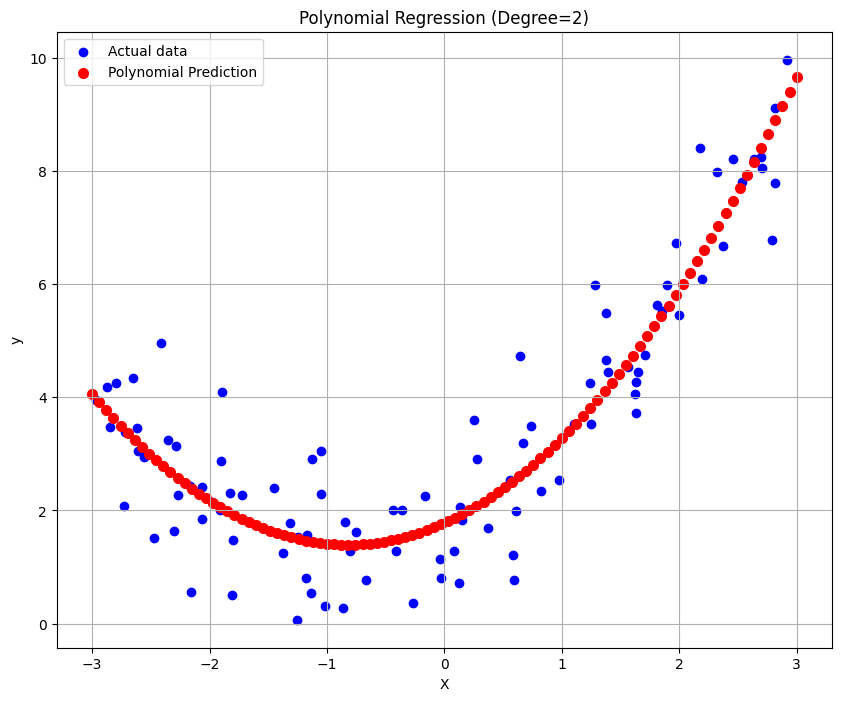

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m,1) - 3 # random number between -3 and 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1) # added noise

poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

model = LinearRegression()
model.fit(X_poly,y) 

print(model.intercept_[0]) # b
print(model.coef_[0][0]) # X
print(model.coef_[0][1]) # x^2

# Plot the smooth prediction
X_new = np.linspace(-3,3,100).reshape(100,1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)

fig,ax = plt.subplots(figsize=(10,8))
ax.scatter(X,y,color="blue",label="Actual data")
ax.scatter(X_new,y_new,color="red",linewidth=2,label="Polynomial Prediction")

ax.set_title("Polynomial Regression (Degree=2)")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.legend(loc="upper left")
plt.grid(True)
plt.show()



## 4) Regularized Linear Models 

**Regularization** is a set of techniques in machine learning to reduce overfitting , by helping the model perform well not only on the training data but also on unseen data.

### 4.0) Dataset Creation 


We create 200 samples with **20 features**, but only **5 features actually matter**.
The other 15 are pure noise. A good regularizer should figure this out.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error

n_samples,n_features = 200,20
n_informative = 5

#True coefficients: first 5 are non-zero , rest are zero
w_true = np.zeros(n_features)
w_true[:n_informative] = [3.0, -2.5, 1.8, -1.2, 0.7]

X = np.random.randn(n_samples,n_features)
y = X@w_true + np.random.randn(n_samples)*0.5 # small noise

# train/test split + standarize (important for regularization!)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"X_train shape {X_train_s.shape} , X_test shape {X_test.shape}")
print(f"True coefficients {w_true}")

X_train shape (140, 20) , X_test shape (60, 20)
True coefficients [ 3.  -2.5  1.8 -1.2  0.7  0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0. ]


### Quick baseline: Ordinary Least Squares (OLS)

The closed-form solution is $\hat{\mathbf{w}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$

With many features relative to samples, OLS tends to **overfit** — let's see.

In [12]:
w_ols = np.linalg.solve(X_train_s.T@X_train_s,X_train_s.T@y_train)

mse_train_ols = mean_squared_error(y_train,X_train_s@w_ols)
mse_test_ols = mean_squared_error(y_test,X_test_s@w_ols)

print(f"OLS — Train MSE: {mse_train_ols:.4f}, Test MSE: {mse_test_ols:.4f}")
print(f"OLS coefficients (rounded): {np.round(w_ols, 2)}")

OLS — Train MSE: 0.2378, Test MSE: 0.3213
OLS coefficients (rounded): [ 2.78 -2.42  1.75 -1.04  0.75  0.06 -0.11 -0.02  0.08 -0.02  0.02 -0.04
  0.05 -0.02 -0.01 -0.01  0.06  0.05 -0.01  0.15]


### 4.1) Ridge Regression

In [13]:
def ridge_closed_form(X,y,alpha):
    """Ridge Regression via closed form solution """
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.solve(X.T @ X + alpha * I,X.T @ y)
    return w 

# try with several alphas values
alphas = [0.001,0.01,0.1,1,10.0,100.0]

for alpha in alphas:
    w = ridge_closed_form(X_train_s,y_train,alpha)
    mse_tr = mean_squared_error(X_train_s@w,y_train)
    mse_te = mean_squared_error(X_test@w,y_test)
    print(f"alpha {alpha} with both : mse_train {mse_tr} and mse_test {mse_te} ")


alpha 0.001 with both : mse_train 0.2378241978627851 and mse_test 0.32951385365099967 
alpha 0.01 with both : mse_train 0.23782431037623408 and mse_test 0.3296013525812161 
alpha 0.1 with both : mse_train 0.2378355416251188 and mse_test 0.3304860846193008 
alpha 1 with both : mse_train 0.2389388884730277 and mse_test 0.34028614117184763 
alpha 10.0 with both : mse_train 0.33225051601308636 and mse_test 0.5153021168422857 
alpha 100.0 with both : mse_train 3.3596497269382493 and mse_test 3.807064801890113 


Let's visualize how each coefficient shrinks as `alpha` increases. Ridge never drives coefficients to zero

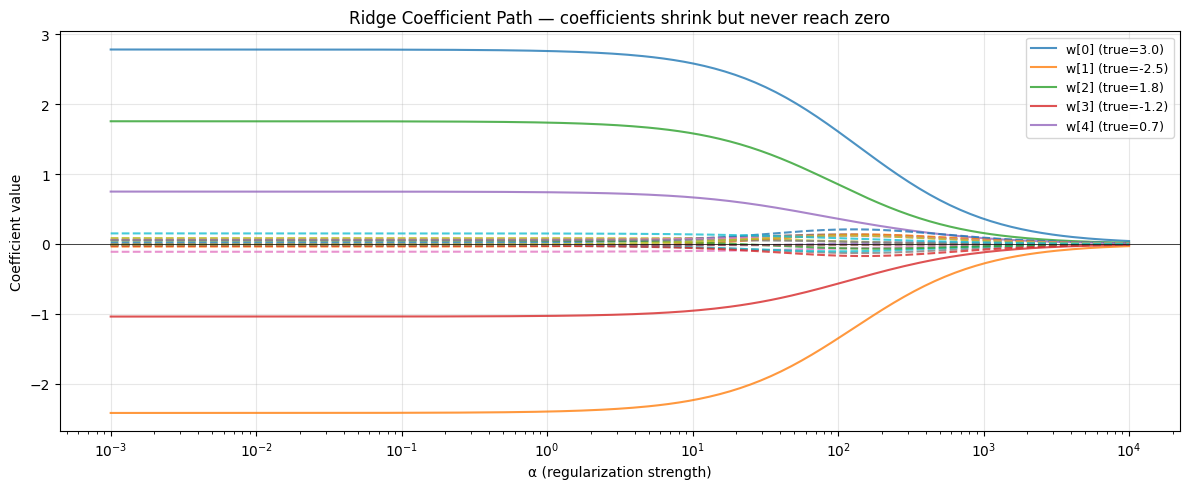

In [16]:
alphas_f = np.logspace(-3,4,200)
ridge_coefs = np.array([ridge_closed_form(X_train_s,y_train,alpha) for alpha in alphas_f])

plt.figure(figsize=(12,5))
for i in range(n_features):
    style = '-' if i < n_informative else '--'
    color = f'C{i%10}'
    label = f'w[{i}] (true={w_true[i]:.1f})' if i < n_informative else None
    plt.plot(alphas_f, ridge_coefs[:, i], style, color=color, alpha=0.8, label=label)

plt.xscale('log')
plt.xlabel('α (regularization strength)')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Path — coefficients shrink but never reach zero')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Using sklearn

In [17]:
from sklearn.linear_model import Ridge 

alpha_test = 1.0
w_ours = ridge_closed_form(X_train_s,y_train,alpha_test)

ridge_sk = Ridge(alpha=alpha_test,fit_intercept=False)
ridge_sk.fit(X_train_s,y_train)

print(f" Max difference : {np.max(np.abs(w_ours-ridge_sk.coef_)):.2e}")

 Max difference : 4.44e-16


### 🧠 Key Takeaway — Ridge

| Aspect | Ridge |
|--------|-------|
| Penalty | $\alpha \sum w_j^2$ |
| What it does | Shrinks ALL coefficients toward zero |
| Feature selection? | ❌ No — keeps all features |
| When to use | Multicollinearity, many mildly useful features |
| Closed form? | ✅ Yes |

## Part2: Lasso Regression (L1 Regularization)
